# UMA Workflow

This notebook implements the general workflow for a UMA calculation and visualization.

### Optional: Jupyter/VS Code notebook kernel

If you want to run this notebook locally, register your UMA virtual environment as a notebook kernel:

```bash
python -m pip install ipykernel
```

Then open this notebook in VS Code or Jupyter and select the venv that supports UMA.

## Calculation

In [1]:
import torch
from pathlib import Path

from mlff_attack.relaxation import (
    load_structure,
    setup_calculator,
    run_relaxation,
    save_results,
)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

input_cif = Path("../Tl4SnTe3.cif")
outdir = Path("output")
traj_path = outdir / "relaxed.traj"
outdir.mkdir(parents=True, exist_ok=True)

In [3]:
atoms = load_structure(input_cif)

if atoms is None:
    raise RuntimeError(f"Failed to load structure from {input_cif}")

atoms

Atoms(symbols='Tl16Sn4Te12', pbc=True, cell=[8.94082, 8.94082, 13.36387], spacegroup_kinds=...)

In [4]:
atoms = setup_calculator(
    atoms,
    "uma-s-1p1",
    device=device,
    calculator="uma",
    uma_task="omat",
    verbose=True,
)

if atoms is None:
    raise RuntimeError("UMA calculator setup failed. Check Hugging Face auth/access.")

atoms

W0527 15:33:23.309000 14192 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Atoms(symbols='Tl16Sn4Te12', pbc=True, cell=[8.94082, 8.94082, 13.36387], spacegroup_kinds=..., calculator=FAIRChemCalculator(...))

In [5]:
energy = atoms.get_potential_energy()
forces = atoms.get_forces()

print("Energy:", energy)
print("Max force:", (forces**2).sum(axis=1).max() ** 0.5)

Energy: -98.01843105346427
Max force: 0.025024828


In [6]:
success = run_relaxation(
    atoms,
    traj_path=traj_path,
    fmax=0.01,
    max_steps=300,
    optimizer="LBFGS",
)
success

True

In [7]:
save_results(atoms, outdir)

WindowsPath('output/relaxed.cif')

## Visualization

In [8]:
from mlff_attack.visualization import load_trajectory, create_visualization

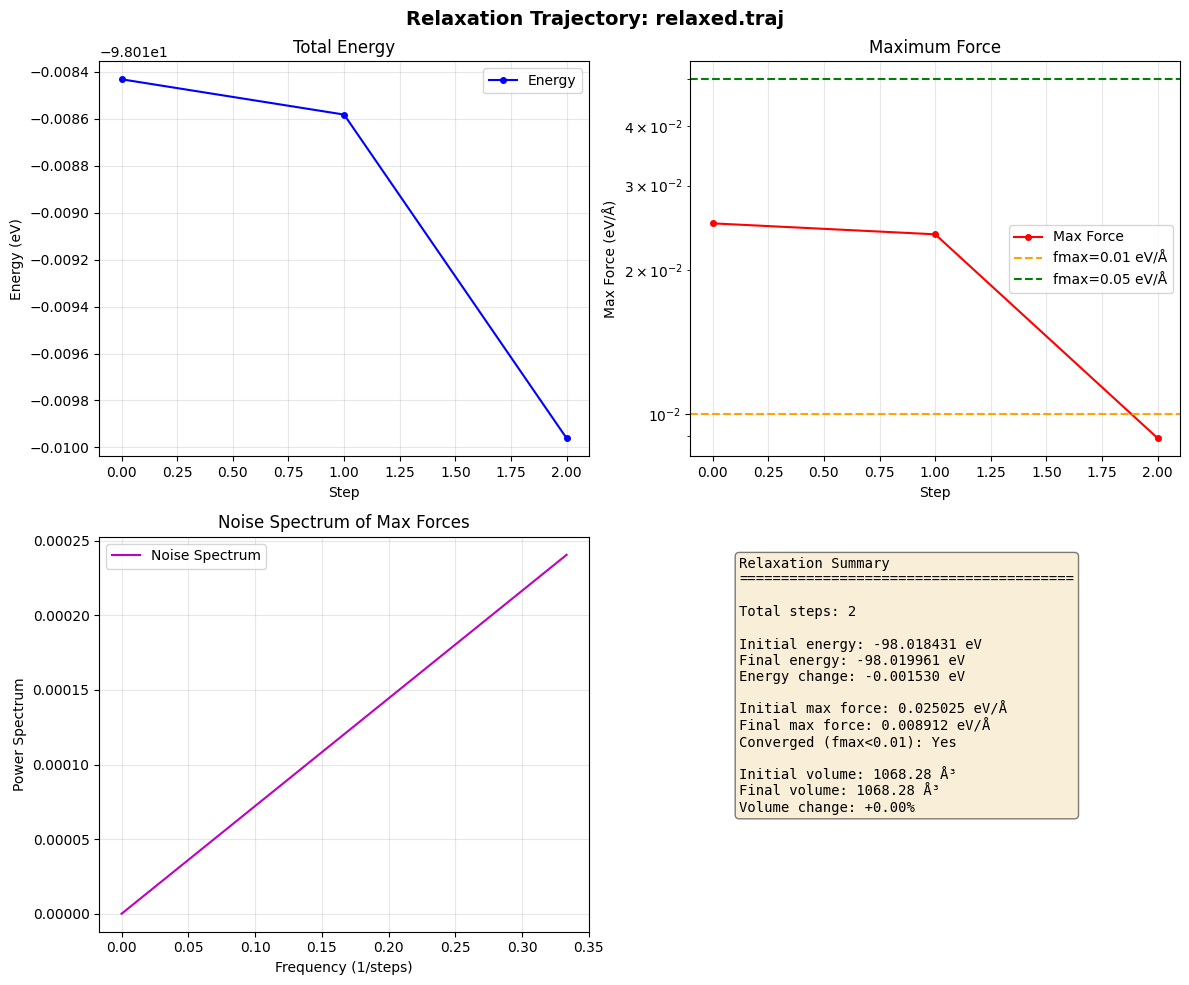

'output\\relaxation_analysis.png'

In [9]:
traj = load_trajectory(traj_path)

if traj is None:
    raise RuntimeError(f"Could not load trajectory from {traj_path}")

visualization_path = create_visualization(
    traj=traj,
    traj_path=traj_path,
    outdir=outdir,
    output_format="png",
    show=True,
)

visualization_path